In [39]:
import pandas as pd
import numpy as np
import random

In [2]:
s = pd.Series(data=[11,22,33], index=['a','b','c'])
print(s)

a    11
b    22
c    33
dtype: int64


In [3]:
p = pd.DataFrame(data={'a':[1,2,3],'b':[4,5,6]})
print(p)

   a  b
0  1  4
1  2  5
2  3  6


In [4]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=1000, n_features=14, n_informative=10, noise=15, random_state=42)
X = pd.DataFrame(X)
y = pd.Series(y)
X.columns = [f'col_{col}' for col in X.columns]

In [5]:
X

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13
0,1.191261,-0.308960,0.675137,-1.460501,0.053059,-1.886129,2.710794,-1.716033,0.865290,0.138078,-0.063745,-2.104583,-0.476876,1.677116
1,1.071476,-1.424766,-1.109750,-0.457677,0.399997,1.587401,-1.547570,0.323247,0.165859,-0.302097,0.203944,-0.212452,0.836991,0.368498
2,-0.045929,1.868603,-0.016568,-0.484258,1.089905,-1.147160,0.590744,0.683325,-0.571184,-0.802199,-0.220114,0.034808,0.043829,0.955803
3,-1.487154,2.220322,0.718332,1.682888,-0.420986,-0.054746,1.900832,-0.101198,0.090042,-0.202924,0.340865,0.606237,-0.037008,-0.841048
4,0.344054,0.657763,0.348342,-0.417430,-0.589112,1.057814,-0.487705,-0.897830,-0.935596,-1.186993,1.074333,-0.069532,-0.177918,-0.912811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.422254,0.576557,-0.646573,-0.756351,-0.127918,1.119575,1.687142,-1.081548,-0.955540,3.078881,0.881640,0.311250,-1.606446,0.203464
996,0.190500,-0.132634,0.709452,0.331980,-2.172670,-0.120381,0.513106,-0.435486,0.847422,1.107081,-0.259547,-0.974529,-0.535328,-0.090533
997,-0.326648,-0.062894,2.002427,-0.650657,1.592964,-0.395284,0.360226,-0.307571,1.465211,0.658143,0.541321,-0.447878,-0.891543,0.069704
998,-1.574342,-1.610263,0.407690,1.149487,1.466442,-0.338669,-2.059160,0.581000,-1.409216,-1.082018,0.798501,0.753190,-1.532598,0.269306


In [6]:
np.ones(14)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

KeyError: 'x'

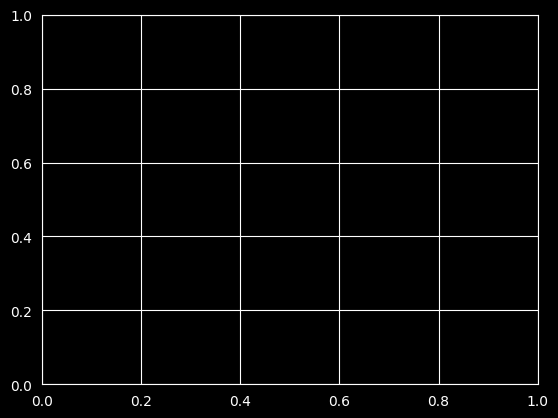

In [7]:
from seaborn import lineplot
lineplot(X=X, y=y)

In [8]:
len(y)

1000

In [9]:
X['xo'] = np.ones(len(y))

In [13]:
len(X)

1000

In [40]:
class MyLineReg:
    def __init__(self, n_iter: int = 100, learning_rate=0.1, weights: list = None, metric: str = None,
                 reg: str = None, l1_coef: float = 0.0, l2_coef: float = 0.0, sgd_sample=None, random_state=42):
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.weights = weights
        self.loss = None
        self.metric = metric
        self.reg = reg
        self.l1_coef = l1_coef
        self.l2_coef = l2_coef
        self.sgd_sample = sgd_sample
        self.random_state = random_state

    def compute_loss(self, y, y_pred, weights):
        metrics_dict = {
            'mse': lambda y, y_pred: np.mean((y - y_pred) ** 2),
            'mae': lambda y, y_pred: np.mean(abs(y - y_pred)),
            'rmse': lambda y, y_pred: np.mean((y - y_pred) ** 2) ** 0.5,
            'r2': lambda y, y_pred: 1 - sum((y - y_pred) ** 2) / sum((y - y.mean()) ** 2),
            'mape': lambda y, y_pred: np.mean(abs((y - y_pred) / y)) * 100,
        }

        loss_function = metrics_dict.get(self.metric, metrics_dict['mse'])
        loss = loss_function(y, y_pred)

        if self.reg == 'l1':
            return loss + self.l1_coef * sum(abs(weights))
        if self.reg == 'l2':
            return loss + self.l2_coef * sum(weights ** 2)
        if self.reg == 'elasticnet':
            return loss + self.l1_coef * sum(abs(weights)) + self.l2_coef * sum(weights ** 2)
        return loss

    def compute_grad(self, grad, weights):
        if self.reg == 'l1':
            return grad + self.l1_coef * np.sign(weights)
        if self.reg == 'l2':
            return grad + self.l2_coef * 2 * weights
        if self.reg == 'elasticnet':
            return grad + self.l1_coef * (np.sign(weights)) + self.l2_coef * 2 * weights
        return grad

    def _get_learning_rate(self, iteration):
        """Получение learning rate на текущей итерации"""
        if callable(self.learning_rate):
            return self.learning_rate(iteration)
        else:
            return self.learning_rate

    def _get_sample_size(self, n_samples):
        """Определение размера мини-пакета"""
        if self.sgd_sample is None:
            return n_samples  # полный датасет

        if isinstance(self.sgd_sample, int):
            return self.sgd_sample
        else:  # дробное число
            return int(n_samples * self.sgd_sample)

    def fit(self, X: pd.DataFrame, y: pd.Series, verbose=False):
        # Фиксируем сид для воспроизводимости
        random.seed(self.random_state)

        # Копия + единичный столбец слева
        X = X.copy()
        X.insert(0, 'x_once', 1.0)

        n_samples, n_features = X.shape
        self.weights = np.ones(n_features)

        # Сохраняем полные данные
        X_full = X.values
        y_full = y.values

        # Определяем размер мини-пакета
        batch_size = self._get_sample_size(n_samples)

        for i in range(1, self.n_iter + 1):
            # Формируем мини-пакет
            if batch_size < n_samples:
                # Случайная выборка индексов
                sample_rows_idx = random.sample(range(n_samples), batch_size)
                X_batch = X_full[sample_rows_idx]
                y_batch = y_full[sample_rows_idx]
            else:
                # Используем все данные
                X_batch = X_full
                y_batch = y_full

            # Предсказание на мини-пакете
            y_pred = X_batch @ self.weights
            error = y_pred - y_batch

            # Вычисляем loss на ПОЛНОМ датасете (для логирования)
            y_pred_full = X_full @ self.weights
            loss = self.compute_loss(y_full, y_pred_full, weights=self.weights)

            if verbose and i == 1:
                print(f"Initial loss: {loss}")

            # Вычисляем градиент на мини-пакете
            grad = (2 / batch_size) * (X_batch.T @ error)
            grad = self.compute_grad(grad, self.weights)

            # Обновляем веса
            lr = self._get_learning_rate(i)
            self.weights = self.weights - lr * grad

            # Вычисляем новый loss на ПОЛНОМ датасете
            y_pred_full_new = X_full @ self.weights
            loss_new = self.compute_loss(y_full, y_pred_full_new, weights=self.weights)

            if verbose and i % verbose == 0:
                print(f"Iteration {i}: loss = {loss_new}")

            self.loss = loss_new

    def get_coef(self) -> np.ndarray:
        return self.weights[1:]

    def get_best_score(self):
        return self.loss

    def predict(self, X: pd.DataFrame):
        X = X.copy()
        X.insert(0, 'x_once', 1.0)
        return X.values @ self.weights  # возвращаем массив, а не сумму

    def __str__(self):
        return f'MyLineReg class: n_iter={self.n_iter}, learning_rate={self.learning_rate}'

In [193]:
X, y = make_regression(n_samples=1000, n_features=14, n_informative=10, noise=15, random_state=42)
X = pd.DataFrame(X)
y = pd.Series(y)

In [194]:
def iteration(iter):
    return 0.5 * (0.85 ** iter)
mld = MyLineReg(50, learning_rate=iteration)
mld.fit(X, y, 10)
print(mld.get_best_score())

20621.089638778492
223.84555459842153
223.7039038429115
223.69410532032137
223.6925008580338
223.69219599716436
223.69219599716436


In [159]:
mld.predict(X).sum().sum()

np.float64(2321.4283735389026)

In [179]:
print(mld)

MyLineReg class: n_iter=50, learning_rate=<function iteration at 0x76eee8e3a9e0>


In [183]:
import random

In [186]:
random.sample(range(X.shape[0]), 3)

[794, 571, 537]

In [187]:
t = 113
b = 0.3

In [190]:
int(t * b)


33

In [191]:
t * b

33.9

In [30]:
import random

import pandas as pd
import numpy as np


class MyLogReg:
    def __init__(self, n_iter: int = 10,
                 learning_rate: float = 0.1,
                 weights: np.ndarray = None,
                 metric: str = None,
                 reg: str = None,
                 l1_coef: float = 0.0,
                 l2_coef: float = 0.0,
                 sgd_sample=None,
                 random_state=42
                 ):

        self.n_iter = n_iter
        self.lr = learning_rate
        self.weights = weights
        self.metric_name = metric
        self.metric = 0
        self.reg = reg
        self.l1_coef = l1_coef
        self.l2_coef = l2_coef
        self.sgd_sample = sgd_sample
        self.random_state = random_state

        self.eps = 1e-15  # чтобы не было логарифма нуля


    def __str__(self):
        return f'MyLogReg class: n_iter={self.n_iter}, learning_rate={self.lr}'

    def _proba_to_class(self, y_pred: np.ndarray) -> np.ndarray:
        y_pred_proba = y_pred > 0.5
        return y_pred_proba.astype(int)

    def _accuracy(self, tp: float, fp: float, tn: float, fn: float) -> float:
        return (tp + tn) / (tp + tn + fp + fn)

    def _f1_score(self, tp: float, fp: float, fn: float) -> float:
        precision = self._precision(tp, fp)
        recall = self._recall(tp, fn)

        if precision + recall == 0:
            return 0

        return 2 * (precision * recall) / (precision + recall)

    def _precision(self, tp: float, fp: float) -> float:
        return tp / (tp + fp)

    def _recall(self, tp: float, fn: float) -> float:
        return tp / (tp + fn)

    def _roc_auc(self, y: np.ndarray, y_pred: np.ndarray) -> float:
        total_pos = np.sum(y == 1)
        total_neg = np.sum(y == 0)

        if total_pos == 0 or total_neg == 0:
            return 0.0

        y_pred = np.round(y_pred, 10)
        sorted_indices = np.argsort(y_pred)[::-1]
        y_sorted = y[sorted_indices]
        score_sorted = y_pred[sorted_indices]

        roc_auc = 0.0
        pos_seen = 0
        i = 0
        n = len(y_sorted)

        while i < n:
            j = i
            while j < n and score_sorted[j] == score_sorted[i]:
                j += 1

            group_positive = np.sum(y_sorted[i:j])
            group_negative = (j - i) - group_positive

            roc_auc += group_negative * pos_seen + group_negative * group_positive / 2
            pos_seen += group_positive
            i = j

        return roc_auc / (total_pos * total_neg)

    def _compute_metric(self, y: np.ndarray, y_pred: np.ndarray) -> float:
        metric = 0.0
        if not self.metric_name:
            return metric

        if self.metric_name == 'roc_auc':
            metric = self._roc_auc(y, y_pred)
            return metric

        y_pred_class = self._proba_to_class(y_pred)

        tp = np.sum((y_pred_class + y) == 2)
        fp = np.sum(y_pred_class > y)
        tn = np.sum((y_pred_class + y) == 0)
        fn = np.sum(y_pred_class < y)

        if self.metric_name == 'accuracy':
            metric = self._accuracy(tp, fp, tn, fn)

        if self.metric_name == 'f1':
            metric = self._f1_score(tp, fp, fn)

        if self.metric_name == 'precision':
            metric = self._precision(tp, fp)

        if self.metric_name == 'recall':
            metric = self._recall(tp, fn)

        return metric

    def _make_prediction(self, X: np.ndarray, weights: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-X @ weights))

    def _compute_loss(self, y: np.ndarray, y_pred: np.ndarray) -> float:
        eps = self.eps
        return -1 * np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))

    def _verbose(self, verbose, iter_count, X, y, weights):
        if verbose and iter_count % verbose == 0:
            y_pred = self._make_prediction(X, weights)
            log_loss = self._compute_loss(y, y_pred)
            self.metric = self._compute_metric(y, y_pred)

            metric_info = f' | {self.metric_name}: {self.metric}' if self.metric_name else ''
            print(f'iter: {iter_count}, loss: {log_loss}{metric_info}')

    def _compute_regularization(self, weights) -> float:
        if (self.reg is None) or (self.reg not in ['l1', 'l2', 'elasticnet']):
            return 0.0

        if self.reg == 'l1':
            return self.l1_coef * np.sign(weights)

        if self.reg == 'l2':
            return self.l2_coef * 2 * weights

        if self.reg == 'elasticnet':
            return self.l1_coef * np.sign(weights) + self.l2_coef * 2 * weights

        return 0.0

    def get_best_score(self):
        return self.metric

    def fit(self, X: pd.DataFrame, y: pd.Series, verbose: int = False):

        X = X.copy()
        X.insert(0, 'x_bias', 1)

        X = X.values
        y = y.values

        n_samples, n_features = X.shape
        weights = self.weights if self.weights is not None else np.ones(n_features)

        random.seed(self.random_state)
        sgd_sample = int(n_features * self.sgd_sample) if isinstance(self.sgd_sample, float) else self.sgd_sample

        batch_size = n_samples if not sgd_sample else sgd_sample

        iter_count = 0

        for iter_ in range(self.n_iter):
            iter_count += 1

            sample_rows_idx = random.sample(range(X.shape[0]), batch_size)
            X_batch = X[sample_rows_idx] if sgd_sample else X
            y_batch = y[sample_rows_idx] if sgd_sample else y

            y_pred_batch = self._make_prediction(X_batch, weights)

            y_pred = self._make_prediction(X, weights)
            self.metric = self._compute_metric(y, y_pred)
            # log_loss = self._compute_loss(y, y_pred)  в этом задании не используем

            regularization = self._compute_regularization(weights)
            grad = (1 / batch_size) * (X_batch.T @ (y_pred_batch - y_batch)) + regularization

            lr = self.lr(iter_count) if callable(self.lr) else self.lr
            weights = weights - lr * grad

            # отладка
            self._verbose(verbose, iter_count, X, y, weights)

        # обновим веса и метрики исходя из последних подсчетов
        y_pred = self._make_prediction(X, weights)
        self._compute_metric(y, y_pred)
        self.weights = weights

    def get_coef(self) -> np.ndarray:
        return self.weights[1:]

    def predict_proba(self, X: pd.DataFrame):
        X = X.copy()
        X.insert(0, 'x_once', 1.0)
        X = X.values
        y_pred = 1 / (1 + np.exp(-X @ self.weights))
        return y_pred

    def predict(self, X: pd.DataFrame):
        X = X.copy()
        X.insert(0, 'x_once', 1.0)
        X = X.values
        y_pred = 1 / (1 + np.exp(-X @ self.weights))
        return self._proba_to_class(y_pred)


In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=14, n_informative=10, random_state=42)
X = pd.DataFrame(X)

y = pd.Series(y)
X.columns = [f'col_{col}' for col in X.columns]

In [82]:
y

0      0
1      0
2      0
3      1
4      1
      ..
995    0
996    1
997    1
998    0
999    0
Length: 1000, dtype: int64

In [62]:
tp, tn = sum((y + y_pred) == 0), sum((y + y_pred) == 2)
fp, fn  = sum(y < y_pred), sum(y > y_pred)

In [65]:
fn + fp + tp + tn

1000

In [67]:
(tp + tn) / (fn + fp + tp + tn)

0.595

In [34]:
cl_reg = MyLogReg(100, 0.01, metric='roc_auc', reg='elasticnet', l1_coef=0.3, sgd_sample=0.1, random_state=42)
cl_reg.fit(X, y, 10)
y_pred = cl_reg.predict(X)
y_pred_prob = cl_reg.predict_proba(X)
print('score: ', cl_reg.get_best_score())

iter: 10, loss: 3.174232030597022 | roc_auc: 0.5264421057684231
iter: 20, loss: 2.8475038953267284 | roc_auc: 0.525938103752415
iter: 30, loss: 2.544690233131032 | roc_auc: 0.5367061468245873
iter: 40, loss: 2.1718831156653224 | roc_auc: 0.5379221516886068
iter: 50, loss: 1.9495114980890953 | roc_auc: 0.5378301513206053
iter: 60, loss: 1.8046080126023025 | roc_auc: 0.5596182384729539
iter: 70, loss: 1.6415696227131147 | roc_auc: 0.575374301497206
iter: 80, loss: 1.4165241786555753 | roc_auc: 0.6102664410657642
iter: 90, loss: 1.3049740369223777 | roc_auc: 0.6208064832259329
iter: 100, loss: 1.2128894171519033 | roc_auc: 0.6325065300261201
score:  0.6325065300261201


In [36]:
cl_reg.get_coef().mean()

np.float64(0.48341958881928065)

In [33]:
prb = cl_reg.predict_proba(X)

In [25]:
tdf = pd.DataFrame({'y': y, 'prb': prb.round(10)}).sort_values(by='prb', ascending=False)

In [4]:
p = next(X.iterrows())

In [44]:
class MySVM:
    def __init__(self, n_iter = 10, learning_rate = 0.001, C = 1, sgd_sample = None, random_state = 42):
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.weights = None
        self.b = 1
        self.C = C
        self.sgd_sample = sgd_sample
        self.random_state = random_state

    def __str__(self):
        return 'MySVM class: n_iter={}, learning_rate={}'.format(self.n_iter, self.learning_rate)

    def fit(self, X: pd.DataFrame, y: pd.Series, verbose = False):
        random.seed(self.random_state)

        X = X.copy()
        X = X.values

        y = y.values
        y = np.where(y == 0, -1, 1)

        n_samples, n_features = X.shape
        weights = np.ones(n_features)
        b = 1

        sgd_sample = int(n_samples * self.sgd_sample) if isinstance(self.sgd_sample, float) else self.sgd_sample
        batch_size = n_samples if not sgd_sample else sgd_sample

        for n in range(1, self.n_iter + 1):
            sample_rows_idx = random.sample(range(n_samples), batch_size)
            X_batch = X if not sgd_sample else X[sample_rows_idx]
            y_batch = y if not sgd_sample else y[sample_rows_idx]

            for i in range(len(X_batch)):
                xi = X_batch[i]
                yi = y_batch[i]

                correct_sign = (yi * (weights @ xi + b)) >= 1
                grad_w = 2 * weights if correct_sign else 2 * weights - self.C * yi * xi
                grad_b = 0 if correct_sign else -self.C * yi

                weights -= self.learning_rate * grad_w
                b -= self.learning_rate * grad_b

            if verbose and (n % verbose == 0 or n == 1):
                loss = weights @ weights + self.C * np.mean(np.maximum(0, 1- yi * (weights @ xi + b)))
                print(f'{n}| loss: {loss}')

        self.weights = weights
        self.b = b

    def get_coef(self):
        return self.weights, self.b

    def predict(self, X: pd.DataFrame):
        X = X.copy()
        X = X.values
        y = np.sign(X @ self.weights + self.b)
        y = np.where(y == -1, 0, 1)
        return y

In [45]:
sdvg = MySVM(50, 0.001)

In [46]:
sdvg.fit(X, y, 10)

1| loss: 2.0623583919464146
10| loss: 1.9522290754217475
20| loss: 1.9545796446671662
30| loss: 1.9545730869847207
40| loss: 1.954573086984706
50| loss: 1.954573086984706


In [32]:
sdvg.predict(X)

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,

In [48]:
len(X.values)

1000